In [1]:
from utils.util import *
from ultralytics import RTDETR
from pathlib import Path
from PIL import ImageFont, ImageDraw
from transformers import SamProcessor, SamModel

In [2]:
detector = RTDETR("../models/object_detection.pt")

detectable_classes = {7: 0, 5: 1, 11: 2, 9: 3, 1: 4}
class_to_model = {0: "efficientnet_b3_missing_cup.pt", 1: "rust_detector_resnet_1.pt", 2: "rust_detector_resnet_2.pt",
                  3: "efficientnet_b3_varigrip.pt", 4: "rust_detector_resnet_4.pt"}
class_to_problem = {0: "Missing cap", 1: "Rust", 2: "Rust", 3: {1: "Rust", 2: "Bird nest"}, 4: "Rust"}

models = {}

sam_model = SamModel.from_pretrained("facebook/sam-vit-huge")#.to("mps")  # or "cuda"/"cpu"
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")


In [3]:
def load_models():
    for i, v in class_to_model.items():
        model_path = os.path.join("../models", v)

        if i == 0:
            model = torchvision_models.efficientnet_b3(weights=None)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
        elif i == 3:
            model = torchvision_models.efficientnet_b3(weights=None)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
        else:
            model = torchvision_models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, 1)

        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()

        models[i] = model

def get_model(class_id):
    return models.get(class_id, None)

In [20]:
def run_full_pipeline(img, image_path: str | Path = "", pad: int = 0):
    """
    • Detect parts with REDETR
    • Crop each part
    • Run defect classifier on the crops
    • Return processed images (object and defect images)
    """

    original_img = img.convert("RGB") if img else Image.open(image_path).convert("RGB")
    img_defections = original_img.copy()
    draw = ImageDraw.Draw(img_defections)

    results = detector.predict(original_img)
    detections = []
    input_boxes = [] # list of tensors
    gradcam_images = [] # list of tensors
    if results:
        for result in results:
            if result.boxes is not None and len(result.boxes) > 0:
                boxes = result.boxes
                confidences = boxes.conf
                cls_indices = boxes.cls

                for box, confidence, class_id in zip(boxes.xyxy, confidences, cls_indices):
                    x1, y1, x2, y2 = box.tolist()
                    c_id = int(class_id)
                    class_name = result.names[c_id]
                    print("Class name: ", class_name)
                    print("Class ID: ", c_id)
                    id = detectable_classes.get(c_id)
                    print("Class ID modified: ", id)
                    if id is not None:
                        crop = crop_object(original_img, box)
                        model = get_model(id)
                        if id == 0:
                            prob, label, heatmap_overlay, raw_cam = predict_image_for_missing_part_with_gradcam(crop, model, "features", DEVICE, 0.5)
                        elif id == 3:
                            prob, label, heatmap_overlay, raw_cam = predict_with_gradcam_bird_nest(crop, model,"features", DEVICE)
                        else:
                            prob, label, heatmap_overlay, raw_cam = predict_image_with_gradcam(crop, model, DEVICE)
                        print(f"Lable: {label} with prob {prob}")

                        if label != 0:
                            draw.rectangle([(x1, y1), (x2, y2)], outline="red", width=3)
                            # draw.text((x1, y1 + 20), class_to_problem[id], fill="red")

                            # Try larger system font
                            try:
                                if os.name == "nt":
                                    font_path = "C:/Windows/Fonts/arial.ttf"
                                else:
                                    font_path = "/System/Library/Fonts/Supplemental/Arial.ttf"
                                font = ImageFont.truetype(font_path, size=24)
                            except OSError:
                                print("Warning: Custom font not found. Using default font.")
                                font = ImageFont.load_default()

                            if id != 3:
                                text = class_to_problem[id]
                            else:
                                text = class_to_problem[id].get(label)

                            # Scale text box if default font is used (bitmap and small)
                            scale = 2.5 if isinstance(font, ImageFont.ImageFont) else 1.0
                            bbox = font.getbbox(text)
                            text_width = int((bbox[2] - bbox[0]) * scale)
                            text_height = int((bbox[3] - bbox[1]) * scale)

                            # Background box and text
                            bg_box = [x1, y1 + 20, x1 + text_width + 6, y1 + 20 + text_height + 4]
                            draw.rectangle(bg_box, fill="red")
                            draw.text((x1 + 3, y1 + 22), text, fill="black", font=font)

                            detections.append(
                                {"id": id, "prob": prob, "label": label, "type": text, "box": box,
                                 "confidence": confidence})

                            gradcam_images.append({"image": heatmap_overlay, "title": class_name, "defect": text})


                if gradcam_images:
                    show_images_horizontal(gradcam_images)

                print("SIZE:")
                print(len([d["box"] for d in detections]))
                print(len(input_boxes))
                print(input_boxes)
                print(f"Detections: {detections}")

                img_object_detection = Image.fromarray(result.plot().astype('uint8'))
                return img_object_detection, img_defections if detections else None

    return original_img, None  # Fallback if no detections


In [5]:
def show_images_horizontal(data, img_height=8):
    n = len(data)
    plt.figure(figsize=(5 * n, img_height))  # Increase height to match vertical clarity

    for i, item in enumerate(data):
        img = item["image"]
        title = item.get("title", "")
        bottom = item.get("defect", "")

        ax = plt.subplot(1, n, i + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=12, pad=10)

        ax.text(
            0.5, -0.15, bottom,
            transform=ax.transAxes,
            fontsize=10,
            ha='center', va='top',
            color='black'
        )

    plt.tight_layout()
    plt.show()

In [6]:
import matplotlib.pyplot as plt

def show_images_vertically(images, titles=None):
    n = len(images)
    plt.figure(figsize=(6, 4 * n))
    for i, img in enumerate(images):
        plt.subplot(n, 1, i + 1)
        plt.imshow(img)
        plt.axis("off")
        if titles:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

In [7]:
load_models()
print(f"Loaded models: {len(models)}")

Loaded models: 5



0: 640x640 1 yoke suspension, 1 glass insulator, 2 vari-grips, 2 polymer insulator upper shackles, 490.6ms
Speed: 9.2ms preprocess, 490.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Class name:  yoke suspension
Class ID:  1
Class ID modified:  4
Lable: 1 with prob 0.9999982118606567
Class name:  vari-grip
Class ID:  9
Class ID modified:  3
Lable: 2 with prob 0.7367048859596252
Class name:  vari-grip
Class ID:  9
Class ID modified:  3
Lable: 1 with prob 0.9204699397087097
Class name:  glass insulator
Class ID:  7
Class ID modified:  0
Lable: 0 with prob 0.22529740631580353
Class name:  polymer insulator upper shackle
Class ID:  11
Class ID modified:  2
Lable: 1 with prob 0.9983445405960083
Class name:  polymer insulator upper shackle
Class ID:  11
Class ID modified:  2
Lable: 0 with prob 0.017637183889746666


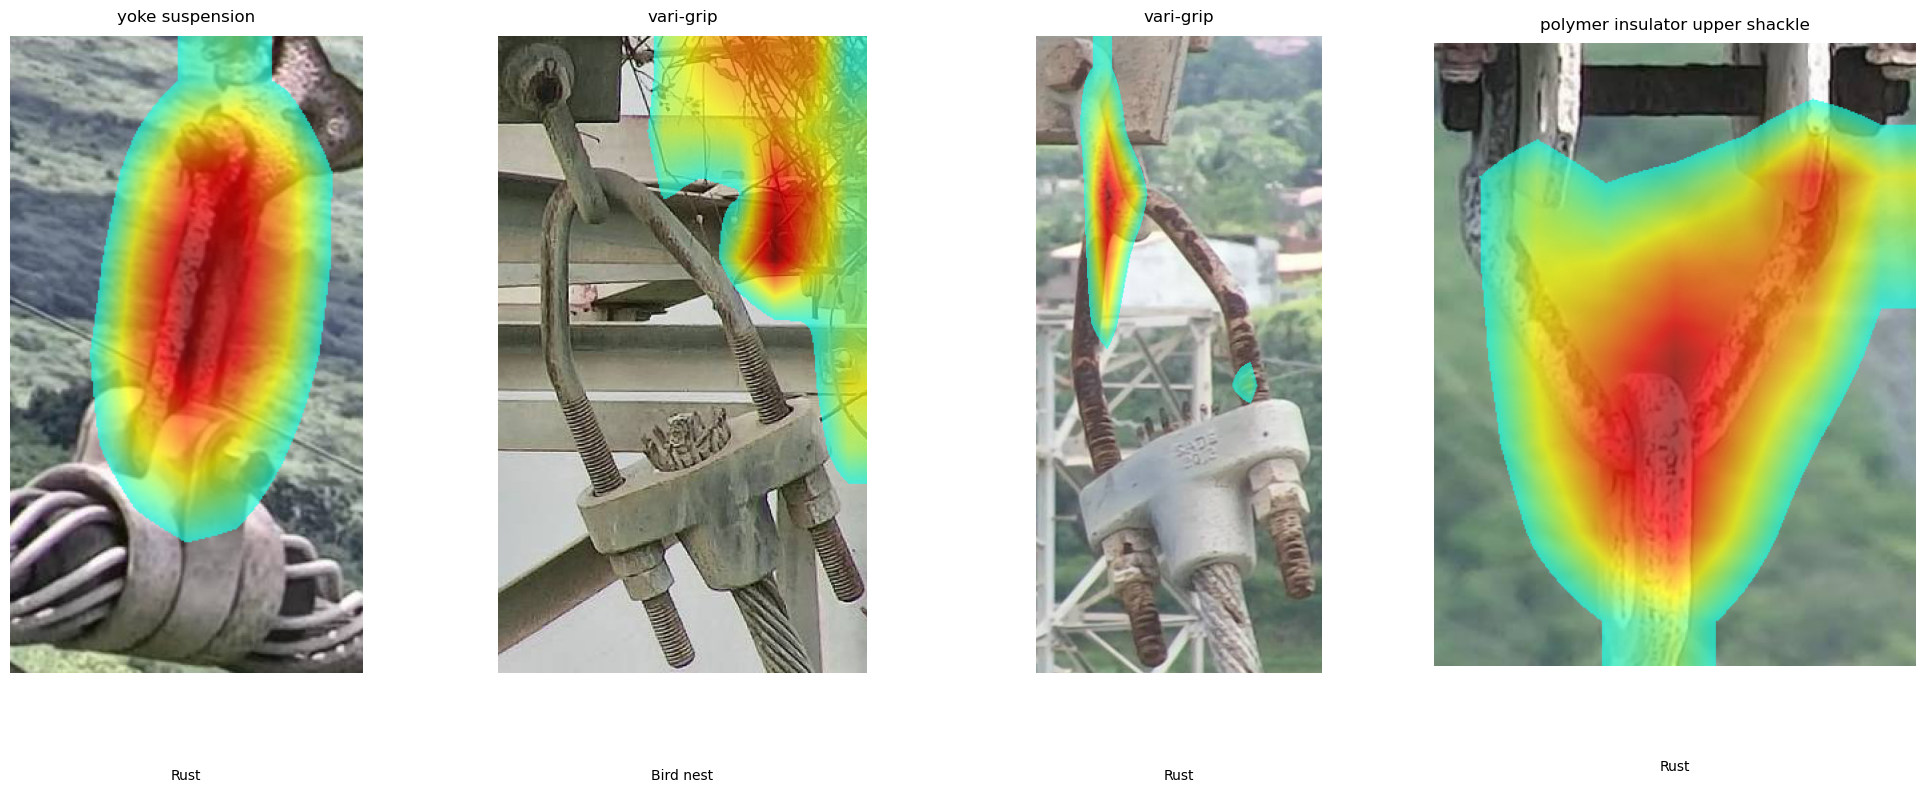

(<PIL.Image.Image image mode=RGB size=1920x1080 at 0x1608CE1D0>, <PIL.Image.Image image mode=RGB size=1920x1080 at 0x160895C10>)


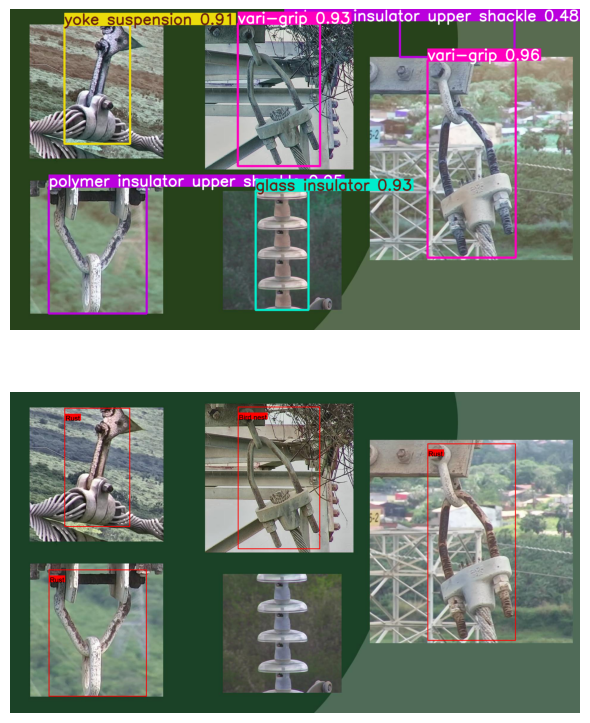

In [31]:
test_img = '/Users/azizbek/Documents/Projects/PowerLine/data/InsPLAD-fault/defect_supervised/glass-insulator/train/missing-cap/Fotos 01-12-2020_DJI_0349_cadeia_isolador_vidro_140_4.jpg'
# test_img = '/Users/azizbek/Documents/Projects/PowerLine/data/InsPLAD-fault/defect_supervised/lightning-rod-suspension/train/rust/01-06-2021_DJI_0092_20_6.jpg'
test_img = '/Users/azizbek/Documents/Projects/PowerLine/data/InsPLAD-fault/defect_supervised/vari-grip/train/bird-nest/08-06-2021_DJI_0089_322_8.jpg'
test_img = '/Users/azizbek/Documents/Projects/PowerLine/data/InsPLAD-fault/defect_supervised/yoke-suspension/train/rust/01-06-2021_DJI_0443_128_1.jpg'
test_img = '/Users/azizbek/Documents/Projects/PowerLine/source/test_combination.jpg'

outputs  = run_full_pipeline(img = None, image_path = test_img)

print(outputs)

show_images_vertically([x for x in outputs if x is not None])